### Assignment 2

#### Submit your assignment as .ipynb

In [2]:
import math
from enum import Enum
from scipy.interpolate import CubicSpline
import numpy as np
import matplotlib.pyplot as plt
import bisect

#### Exercise 1.

Implement a trinomial tree that takes the below signature:

In [3]:
def trinomialPricer(S, r, q, vol, trade, n, lmda):
    t = trade.expiry / n
    u = math.exp(lmda * vol * math.sqrt(t))
    mu = r-q
    stdev = vol*math.sqrt(t)
    pu = 1 / 2 / lmda / lmda + (mu - vol * vol / 2) / 2 / lmda / vol * math.sqrt(t)
    pd = 1 / 2 / lmda / lmda - (mu - vol * vol / 2) / 2 / lmda / vol * math.sqrt(t)
    pm = 1 - pu - pd

    vs = [trade.payoff(S * u ** (n - i)) for i in range(2*n + 1)]
    ##
    for i in range(n - 1, -1, -1):
        # calculate the value of each node at time slide i, there are i nodes
        for j in range(2*i + 1):
            nodeS = S * u ** (i - j)
            continuation = math.exp(-r * t) * (vs[j] * pu +  + vs[j+1] * pm + vs[j+2] * pd)
            vs[j] = trade.valueAtNode(t * i, nodeS, continuation)
    return vs[0]

In [4]:
def trinomialPricerAnchor(S, r, q, vol, trade, n, K):
  t = trade.expiry / n
  lmda = np.sqrt(3)
  u = math.exp(lmda * vol * math.sqrt(t))
  mu = r - q

  #Build the tree
  vs_1 = [(S * u ** (n - i)) for i in range(2*n + 1)]
  vs_k = [abs(i - K) for i in vs_1] #difference between node values and strike for the pricing
  closest_node = vs_k.index(min(vs_k)) #finds which value is closest to K

  if closest_node != n:
        #lmda = range(1,2)
        lmda = (math.log(K/S))/(n-closest_node) / vol / math.sqrt(t)
        #lmda = (math.log(K/S))/(n-closest_node) / math.sqrt(t)

  elif closest_node == n:
        lmda = math.sqrt(3)

  # Recalculate
  u = math.exp(lmda * vol * math.sqrt(t))
  pu = 1 / 2 / lmda / lmda + (mu - vol * vol / 2) / 2 / lmda / vol * math.sqrt(t)
  pd = 1 / 2 / lmda / lmda - (mu - vol * vol / 2) / 2 / lmda / vol * math.sqrt(t)
  pm = 1 - pu - pd
  vs_1 = [(S * u ** (n - i)) for i in range(2*n + 1)]
  #vs_k = [abs(i - K) for i in vs_1]
  #closest_node = vs_k.index(min(vs_k))
  #print(f'Updated closest node is {closest_node} at {vs_1[closest_node]} when lambda = {lmda}')
  vs_1 = [trade.payoff(S * u ** (n - i)) for i in range(2*n + 1)]
  ##
  for i in range(n - 1, -1, -1):
      # calculate the value of each node at time slide i, there are i nodes
      for j in range(2*i + 1):
          nodeS = S * u ** (i - j)
          continuation = math.exp(-r * t) * (vs_1[j] * pu +  + vs_1[j+1] * pm + vs_1[j+2] * pd)
          vs_1[j] = trade.valueAtNode(t * i, nodeS, continuation)
  return vs_1[0]

Instead of taking the parameter $\lambda$ in our example code, this function takes a discontinuity K and anchors a tree node to K by tuning $\lambda$ inside the pricer.
Note that there are many ways to adjust $\lambda$, one example is to construct the tree with $\lambda = \sqrt{3}$ first, find the node closest to $K$, then adjust $\lambda$ such that the node falls on $K$, but you are free to define your own way to achieve this.

Plot the pricing errors of this trinomial tree pricer with the market and strike below, for number of tree steps from 10 to 300 (similar to our binomial tree test cases).
Use a European Call option and a Binary Call option as test trades.

In [5]:
class PayoffType(str, Enum):
    Call = 'Call'
    Put = 'Put'
    BinaryCall = 'BinaryCall'

class EuropeanOption():
  def __init__(self, expiry, strike, payoffType):
        self.expiry = expiry
        self.strike = strike
        self.payoffType = payoffType
  def payoff(self, S):
        if self.payoffType == PayoffType.Call:
            return max(S - self.strike, 0)
        elif self.payoffType == PayoffType.Put:
            return max(self.strike - S, 0)
        elif self.payoffType == PayoffType.BinaryCall:
            if S > self.strike:
                return 1.0
            else:
                return 0.0
        elif self.payoffType == PayoffType.BinaryPut:
            if S < self.strike:
                return 1.0
            else:
                return 0.0
        else:
            raise Exception("payoffType not supported: ", self.payoffType)
  def valueAtNode(self, t, S, continuation):
        if continuation == None:
            return self.payoff(S)
        else:
            return continuation

def bsPrice(S, r, vol, T, strike, payoffType):
    fwd = S * math.exp(r * T)
    stdev = vol * math.sqrt(T)
    d1 = math.log(fwd / strike) / stdev + stdev / 2
    d2 = d1 - stdev
    if payoffType == PayoffType.Call:
        return math.exp(-r * T) * (fwd * cnorm(d1) - cnorm(d2) * strike)
    elif payoffType == PayoffType.Put:
        return math.exp(-r * T) * (strike * cnorm(-d2) - cnorm(-d1) * fwd)
    elif payoffType == PayoffType.BinaryCall:
        return math.exp(-r * T) * cnorm(d1)
    elif payoffType == PayoffType.BinaryPut:
        return math.exp(-r * T) * (1-cnorm(-d1))
    else:
        raise Exception("not supported payoff type", payoffType)

def cnorm(x):
    return (1.0 + math.erf(x / math.sqrt(2.0))) / 2.0

In [6]:
K = 105
S, r, vol = 100, 0.01, 0.2
T=1

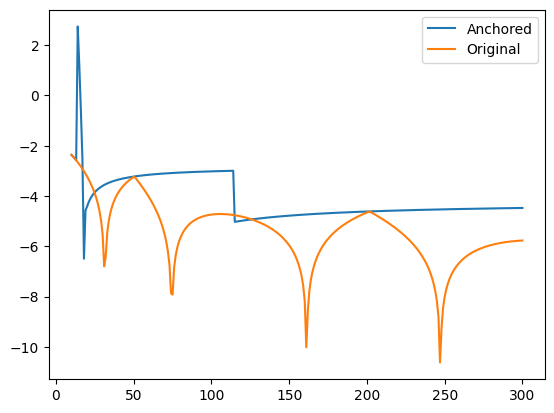

In [7]:
#European call
bsCall = bsPrice(S, r, vol, T, K, PayoffType.Call)
triErrs = [math.log(abs(trinomialPricer(S, r, 0, vol, EuropeanOption(T, K, PayoffType.Call), i , math.sqrt(3)) - bsCall)) for i in range(10, 301)]
triErrs1 = [math.log(abs(trinomialPricerAnchor(S, r, 0, vol, EuropeanOption(T, K, PayoffType.Call), i , K) - bsCall)) for i in range(10, 301)]

plt.plot(range(10,301), triErrs1, label='Anchored')
plt.plot(range(10,301), triErrs, label='Original')
plt.legend()
plt.show()

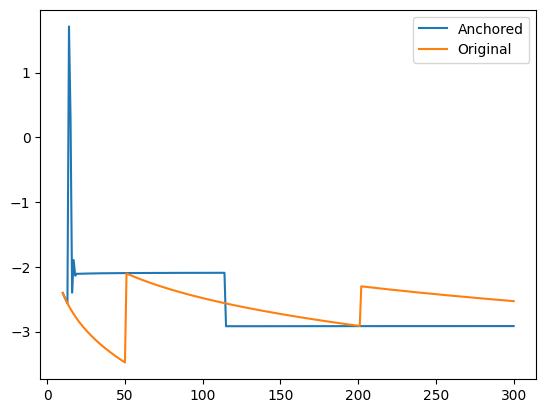

In [8]:
#binary call
bsBinaryCall = bsPrice(S, r, vol, T, K, PayoffType.BinaryCall)
triErrs = [math.log(abs(trinomialPricer(S, r, 0, vol, EuropeanOption(T, K, PayoffType.BinaryCall), i , math.sqrt(3)) - bsBinaryCall)) for i in range(10, 301)]
triErrs1 = [math.log(abs(trinomialPricerAnchor(S, r, 0, vol, EuropeanOption(T, K, PayoffType.BinaryCall), i , K) - bsBinaryCall)) for i in range(10, 301)]

plt.plot(range(10,301), triErrs1, label='Anchored')
plt.plot(range(10,301), triErrs, label='Original')
plt.legend()
plt.show()

#### Exercise 2.

Assuming forward delta convention, implement below function ```strikeFromdelta``` that calculates the strike from a given delta.
You may use the ```fwdDelta``` function below. Test with below:

S, r, q, T, vol, delta, payoffType = 100, 0.1, 0, 1, 0.1, 0.25, PayoffType.Put

In [26]:
def bisect1(f, a, b, tol):
    assert(a < b and f(a) * f(b) < 0)
    c = (a+b) / 2
    while (b-a)/2 > tol:
        print("(a, b) = (", a, ",", b, ")")
        c = (a+b)/2
        if abs(f(c)) < tol:
            return c
        else:
            if f(a) * f(c) < 0:
                b = c
            else:
                a = c
    return c

In [27]:
from scipy.optimize import brentq
class PayoffType(Enum):
    Call = 0
    Put = 1
def cnorm(x):
    return (1.0 + math.erf(x / math.sqrt(2.0))) / 2.0

def fwdDelta(fwd, stdev, strike, payoffType):
    d1 = math.log(fwd / strike) / stdev + stdev / 2
    if payoffType == PayoffType.Call:
        return cnorm(d1)
    elif payoffType == PayoffType.Put:
        return -cnorm(-d1)
    else:
        raise Exception("not supported payoff type", payoffType)


def strikeFromDelta(S, r, q, T, vol, delta, a, b, tol, payoffType):
    F = S * np.exp((r-q)*T)
    f = lambda strike: fwdDelta(F, vol, strike, payoffType) - delta
    strike = bisect1(f, a, b, tol)
    return strike


In [28]:
S, r, q, T, vol, delta, a, b, tol, payoffType = 100, 0.1, 0, 1, 0.1, -0.25, 50, 150, 1e-7, PayoffType.Put
strikeFromDelta(S, r, q, T, vol, delta, a, b, tol, payoffType)

(a, b) = ( 50 , 150 )
(a, b) = ( 100.0 , 150 )
(a, b) = ( 100.0 , 125.0 )
(a, b) = ( 100.0 , 112.5 )
(a, b) = ( 100.0 , 106.25 )
(a, b) = ( 103.125 , 106.25 )
(a, b) = ( 103.125 , 104.6875 )
(a, b) = ( 103.125 , 103.90625 )
(a, b) = ( 103.515625 , 103.90625 )
(a, b) = ( 103.7109375 , 103.90625 )
(a, b) = ( 103.80859375 , 103.90625 )
(a, b) = ( 103.80859375 , 103.857421875 )
(a, b) = ( 103.80859375 , 103.8330078125 )
(a, b) = ( 103.82080078125 , 103.8330078125 )
(a, b) = ( 103.82080078125 , 103.826904296875 )
(a, b) = ( 103.8238525390625 , 103.826904296875 )
(a, b) = ( 103.82537841796875 , 103.826904296875 )
(a, b) = ( 103.82614135742188 , 103.826904296875 )
(a, b) = ( 103.82614135742188 , 103.82652282714844 )
(a, b) = ( 103.82633209228516 , 103.82652282714844 )
(a, b) = ( 103.8264274597168 , 103.82652282714844 )
(a, b) = ( 103.82647514343262 , 103.82652282714844 )


103.82649898529053

#### Exercise 3.

Implement ```smilefromMarks``` function below, it take the time to maturity $T$, current stop price $S$, risk free and dividend rate $r$ and $q$,
ATM volatility, BF25, RR25, BF10, RR10 quotes, returns a CubicSpline interpolated smile for this pillar. We assume ATM forward convention.
You may use the Smile class provided below.   

In [29]:
class Smile:
    def __init__(self, strikes, vols):
        # add additional point on the right to avoid arbitrage
        self.strikes = strikes  + [1.1*strikes[-1] - 0.1*strikes[-2]]
        self.vols = vols + [vols[-1] + (vols[-1]-vols[-2])/10]
        self.cs = CubicSpline(strikes, vols, bc_type=((1, 0.0), (1, 0.0)), extrapolate=True)
    def Vol(self, k):
        if k < self.strikes[0]:  # scipy cubicspline bc_type confusing, extrapolate by ourselfs
            return self.vols[0]
        if k > self.strikes[-1]:
            return self.vols[-1]
        else:
            return self.cs(k)

a, b, tol = 0.5, 3, 1e-7

def smileFromMarks(T, S, r, q, atmvol, bf25, rr25, bf10, rr10):
    vol_P_25 = bf25 + atmvol - 0.5 * rr25
    vol_P_10 = bf10 + atmvol - 0.5 * rr10
    vol_C_25 = 0.5 * rr25 + bf25 + atmvol
    vol_C_10 = 0.5 * rr10 + bf10 + atmvol

    K_Call_25 = strikeFromDelta(S, r, q, T, vol_C_25, 0.25, a, b, tol , PayoffType.Call)
    K_Put_25 = strikeFromDelta(S, r, q, T, vol_P_25, -0.25, a, b, tol, PayoffType.Put)
    K_Call_10 = strikeFromDelta(S, r, q, T, vol_C_10, 0.1, a, b, tol , PayoffType.Call)
    K_Put_10 = strikeFromDelta(S, r, q, T, vol_P_10, -0.1, a, b, tol , PayoffType.Put)
    K_atm = S * math.exp((r-q)*T)

    strikes = [K_Put_10, K_Put_25, K_atm, K_Call_25, K_Call_10]
    vols = [vol_P_10, vol_P_25, atmvol, vol_C_25, vol_C_10]
    return Smile(strikes, vols)

With ```smileFromMarks```, we can prepare our implied volatility surface from input marks.

In [30]:
class ImpliedVol:
    def __init__(self, ts, smiles):
        self.ts = ts
        self.smiles = smiles
    # linear interpolation in variance, along the strike line
    def Vol(self, t, k):
        # locate the interval t is in
        pos = bisect.bisect_left(self.ts, t)
        # if t is on or in front of first pillar,
        if pos == 0:
            return self.smiles[0].Vol(k)
        if pos >= len(self.ts):
            return self.smiles[-1].Vol(k)
        else:  # in between two brackets
            prevVol, prevT = self.smiles[pos-1].Vol(k), self.ts[pos-1]
            nextVol, nextT = self.smiles[pos].Vol(k), self.ts[pos]
            w = (nextT - t) / (nextT - prevT)
            prevVar = prevVol * prevVol * prevT
            nextVar = nextVol * nextVol * nextT
            return  math.sqrt((w * prevVar + (1-w) * nextVar)/t)
        return
    def dVoldK(self, t, k):
        return (self.Vol(t, k+0.01) - self.Vol(t, k-0.01)) / 0.02
    def dVoldT(self, t, k):
        return (self.Vol(t+0.005, k) - self.Vol(t, k)) / 0.005
    def dVol2dK2(self, t, k):
        return (self.Vol(t, k+0.01) + self.Vol(t, k-0.01) - 2*self.Vol(t, k)) / 0.0001

Plot the test implied volatility surface using below test functions.

(a, b) = ( 0.5 , 3 )
(a, b) = ( 0.5 , 1.75 )
(a, b) = ( 1.125 , 1.75 )
(a, b) = ( 1.125 , 1.4375 )
(a, b) = ( 1.28125 , 1.4375 )
(a, b) = ( 1.359375 , 1.4375 )
(a, b) = ( 1.3984375 , 1.4375 )
(a, b) = ( 1.3984375 , 1.41796875 )
(a, b) = ( 1.408203125 , 1.41796875 )
(a, b) = ( 1.408203125 , 1.4130859375 )
(a, b) = ( 1.41064453125 , 1.4130859375 )
(a, b) = ( 1.41064453125 , 1.411865234375 )
(a, b) = ( 1.4112548828125 , 1.411865234375 )
(a, b) = ( 1.41156005859375 , 1.411865234375 )
(a, b) = ( 1.411712646484375 , 1.411865234375 )
(a, b) = ( 1.4117889404296875 , 1.411865234375 )
(a, b) = ( 1.4118270874023438 , 1.411865234375 )
(a, b) = ( 1.4118270874023438 , 1.4118461608886719 )
(a, b) = ( 1.4118366241455078 , 1.4118461608886719 )
(a, b) = ( 1.4118366241455078 , 1.4118413925170898 )
(a, b) = ( 1.4118390083312988 , 1.4118413925170898 )
(a, b) = ( 1.4118402004241943 , 1.4118413925170898 )
(a, b) = ( 1.4118402004241943 , 1.411840796470642 )
(a, b) = ( 1.4118402004241943 , 1.4118404984474182 )

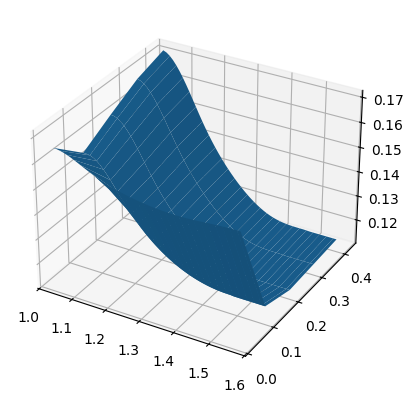

In [31]:
import bisect
def createTestImpliedVol(S, r, q):
    pillars = [0.02, 0.04, 0.06, 0.08, 0.16, 0.25, 0.75, 1.0, 1.5, 2, 3, 5] # in year
    atmvols = [0.155, 0.1395, 0.1304, 0.1280, 0.1230, 0.1230, 0.1265, 0.1290, 0.1313, 0.1318, 0.1313, 0.1305, 0.1295]
    bf25s = [0.0016, 0.0016, 0.0021, 0.0028, 0.0034, 0.0043, 0.0055, 0.0058, 0.0060, 0.0055, 0.0054, 0.0050, 0.0045, 0.0043]
    rr25s = [-0.0065, -0.0110, -0.0143, -0.0180, -0.0238, -0.0288, -0.0331, -0.0344, -0.0349, -0.0340, -0.0335, -0.0330, -0.0330]
    bf10s = [0.0050, 0.0050, 0.0067, 0.0088, 0.0111, 0.0144, 0.0190, 0.0201, 0.0204, 0.0190, 0.0186, 0.0172, 0.0155, 0.0148]
    rr10s = [-0.0111, -0.0187, -0.0248, -0.0315, -0.0439, -0.0518, -0.0627, -0.0652, -0.0662, -0.0646, -0.0636, -0.0627, -0.0627]
    smiles = [smileFromMarks(pillars[i], S, r, q, atmvols[i], bf25s[i], rr25s[i], bf10s[i], rr10s[i]) for i in range(len(pillars))]
    return ImpliedVol(pillars, smiles)

def plotTestImpliedVolSurface():
    S, r, q = 1.25805, 0.01, 0.003
    iv = createTestImpliedVol(S, r, q)
    tStart, tEnd = 0.02, 0.5
    ts = np.arange(tStart, tEnd, 0.1)
    fwdEnd = S*math.exp((r-q)*tEnd)
    kmin = strikeFromDelta(S, r, q, tEnd, iv.Vol(tEnd, fwdEnd), -0.05, a, b, tol, PayoffType.Put)
    kmax = strikeFromDelta(S, r, q, tEnd, iv.Vol(tEnd, fwdEnd), 0.05, a, b, tol, PayoffType.Call)
    ks = np.arange(kmin, kmax, 0.01)

    vs = np.ndarray((len(ts), len(ks)))
    for i in range(len(ts)):
        for j in range(len(ks)):
            vs[i, j] = iv.Vol(ts[i], ks[j])
    hf = plt.figure()
    ha = hf.add_subplot(111, projection='3d')
    X, Y = np.meshgrid(ks, ts)
    ha.plot_surface(X, Y, vs)
    plt.show()
plotTestImpliedVolSurface()